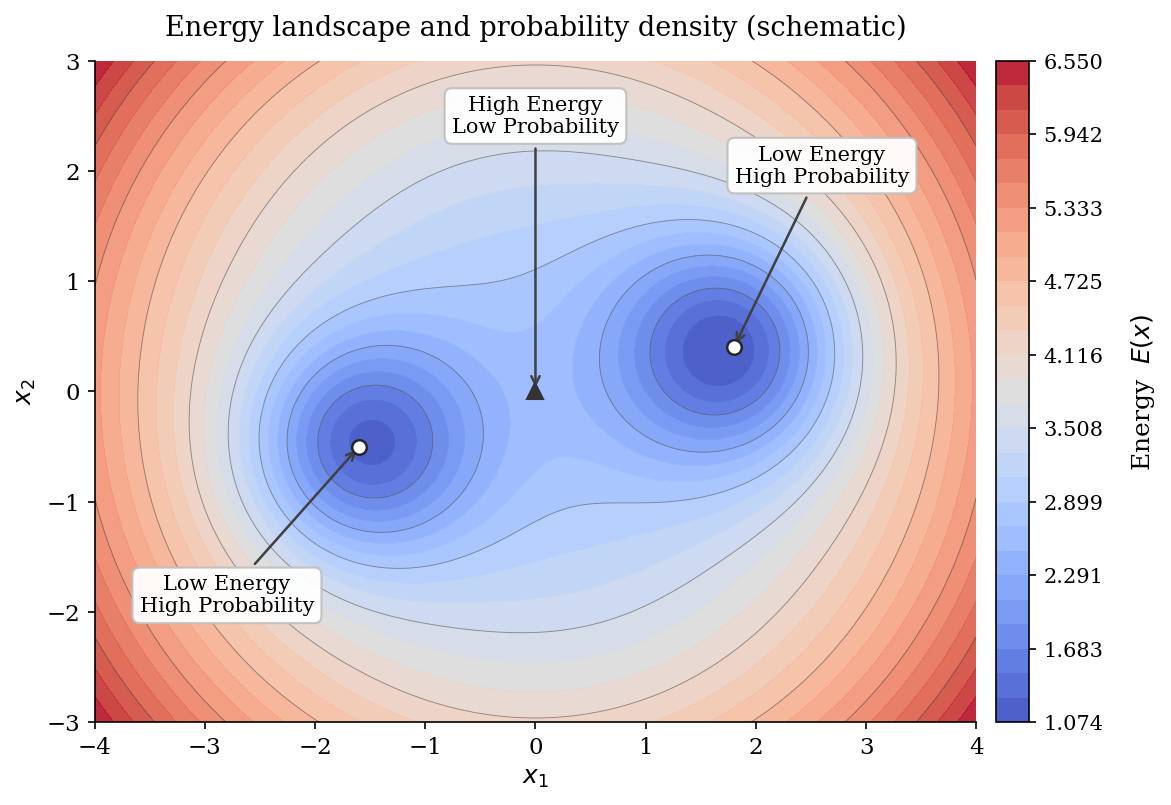

In [1]:
"""Energy landscape: two low-energy valleys (high probability) and intervening peaks."""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Presentation style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Grid
x = np.linspace(-4, 4, 400)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

# Smooth bimodal energy: two Gaussian wells + mild background curvature
# Low E at valleys → high probability under p(x) ∝ exp(-E(x))
E = (
    0.15 * (X**2 + Y**2)
    + 2.8
    - 2.2 * np.exp(-((X - 1.8) ** 2 + (Y - 0.4) ** 2) / 1.1)
    - 2.0 * np.exp(-((X + 1.6) ** 2 + (Y + 0.5) ** 2) / 1.0)
)

# Valley and peak locations (approximate minima / saddle between wells)
valley_1 = (1.8, 0.4)
valley_2 = (-1.6, -0.5)
peak = (0.0, 0.0)

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)

levels = np.linspace(E.min(), E.max(), 28)
cf = ax.contourf(X, Y, E, levels=levels, cmap=cm.coolwarm, alpha=0.92)
cs = ax.contour(X, Y, E, levels=levels[::3], colors="0.35", linewidths=0.45, alpha=0.6)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("Energy  $E(x)$", rotation=90, labelpad=12)
cbar.ax.tick_params(labelsize=10)

# Mark extrema
ax.plot(*valley_1, "o", color="white", markersize=7, markeredgecolor="0.15", markeredgewidth=1.2, zorder=5)
ax.plot(*valley_2, "o", color="white", markersize=7, markeredgecolor="0.15", markeredgewidth=1.2, zorder=5)
ax.plot(*peak, "^", color="0.2", markersize=8, zorder=5)

# Annotations
bbox = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.95)
ax.annotate(
    "Low Energy\nHigh Probability",
    xy=valley_1,
    xytext=(2.6, 1.9),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)
ax.annotate(
    "Low Energy\nHigh Probability",
    xy=valley_2,
    xytext=(-2.8, -2.0),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)
ax.annotate(
    "High Energy\nLow Probability",
    xy=peak,
    xytext=(0.0, 2.35),
    fontsize=10,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.25", lw=1.2),
    bbox=bbox,
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Energy landscape and probability density (schematic)", pad=12)
ax.set_aspect("equal")
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig("../runs/energy_landscape.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

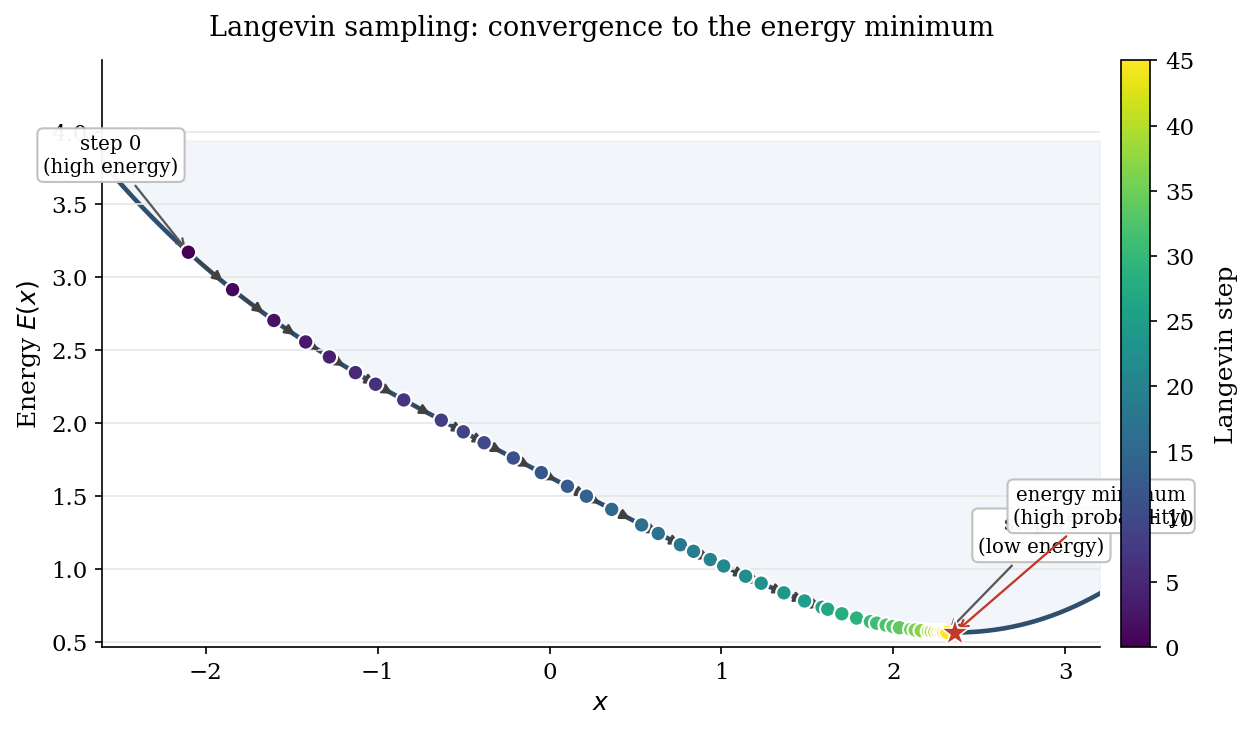

Final x = 2.310, minimum at x = 2.358 (Δ = 0.047)


In [3]:
"""1D energy landscape — Langevin trajectory converging to the energy minimum."""

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Smooth 1D energy with a clear minimum (schematic)
def energy(x: np.ndarray) -> np.ndarray:
    return 0.22 * (x - 1.4) ** 2 + 0.55 * np.cos(0.9 * x) + 0.65


def energy_grad(x: float) -> float:
    eps = 1e-5
    return float((energy(x + eps) - energy(x - eps)) / (2 * eps))


# True minimum of E(x) on the plotted domain (for reference marker)
x_grid_fine = np.linspace(-2.6, 3.2, 5000)
x_min = float(x_grid_fine[np.argmin(energy(x_grid_fine))])
e_min = float(energy(x_min))

# Langevin dynamics with annealed noise → converges near the minimum
rng = np.random.default_rng(7)
x_pos = -2.1
alpha = 0.24
sigma = 0.055
n_steps = 45

trajectory = [x_pos]
for t in range(n_steps):
    # less noise toward the end so the chain can settle in the valley
    noise_scale = sigma * (0.1 + 0.9 * (1.0 - t / max(n_steps - 1, 1)))
    x_pos = x_pos - alpha * energy_grad(x_pos) + noise_scale * rng.standard_normal()
    trajectory.append(x_pos)

trajectory = np.array(trajectory)
energies = energy(trajectory)

# Plot curve
x_grid = np.linspace(-2.6, 3.2, 500)
E_grid = energy(x_grid)

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=150)
ax.fill_between(x_grid, E_grid, E_grid.max() + 0.15, color="#e8eef5", alpha=0.55, zorder=0)
ax.plot(x_grid, E_grid, color="#2f4f6f", linewidth=2.2, zorder=1)

# True minimum on the curve (reference)
ax.plot(x_min, e_min, marker="*", markersize=14, color="#c0392b", markeredgecolor="white",
        markeredgewidth=0.8, zorder=5)

# Sampling steps
ax.scatter(
    trajectory,
    energies,
    s=55,
    c=np.arange(len(trajectory)),
    cmap="viridis",
    edgecolors="white",
    linewidths=1.0,
    zorder=4,
)

# Arrows between consecutive steps
for i in range(len(trajectory) - 1):
    ax.annotate(
        "",
        xy=(trajectory[i + 1], energies[i + 1]),
        xytext=(trajectory[i], energies[i]),
        arrowprops=dict(
            arrowstyle="-|>",
            color="0.25",
            lw=1.2,
            shrinkA=6,
            shrinkB=6,
            mutation_scale=10,
        ),
        zorder=3,
    )

bbox = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.75", alpha=0.95)

ax.annotate(
    "step 0\n(high energy)",
    xy=(trajectory[0], energies[0]),
    xytext=(trajectory[0] - 0.45, energies[0] + 0.55),
    fontsize=9.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.1),
    bbox=bbox,
)
ax.annotate(
    f"step {n_steps}\n(low energy)",
    xy=(trajectory[-1], energies[-1]),
    xytext=(trajectory[-1] + 0.55, energies[-1] + 0.55),
    fontsize=9.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.1),
    bbox=bbox,
)
ax.annotate(
    "energy minimum\n(high probability)",
    xy=(x_min, e_min),
    xytext=(x_min + 0.85, e_min + 0.75),
    fontsize=9.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.1),
    bbox=bbox,
)

ax.set_xlabel("$x$")
ax.set_ylabel("Energy $E(x)$")
ax.set_title("Langevin sampling: convergence to the energy minimum", pad=12)
ax.set_xlim(-2.6, 3.2)
ax.set_ylim(E_grid.min() - 0.1, E_grid.max() + 0.7)
ax.grid(axis="y", color="0.9", linewidth=0.8, zorder=0)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, n_steps))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.04)
cbar.set_label("Langevin step", rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("../runs/langevin_trajectory_1d.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Final x = {trajectory[-1]:.3f}, minimum at x = {x_min:.3f} (Δ = {abs(trajectory[-1]-x_min):.3f})")

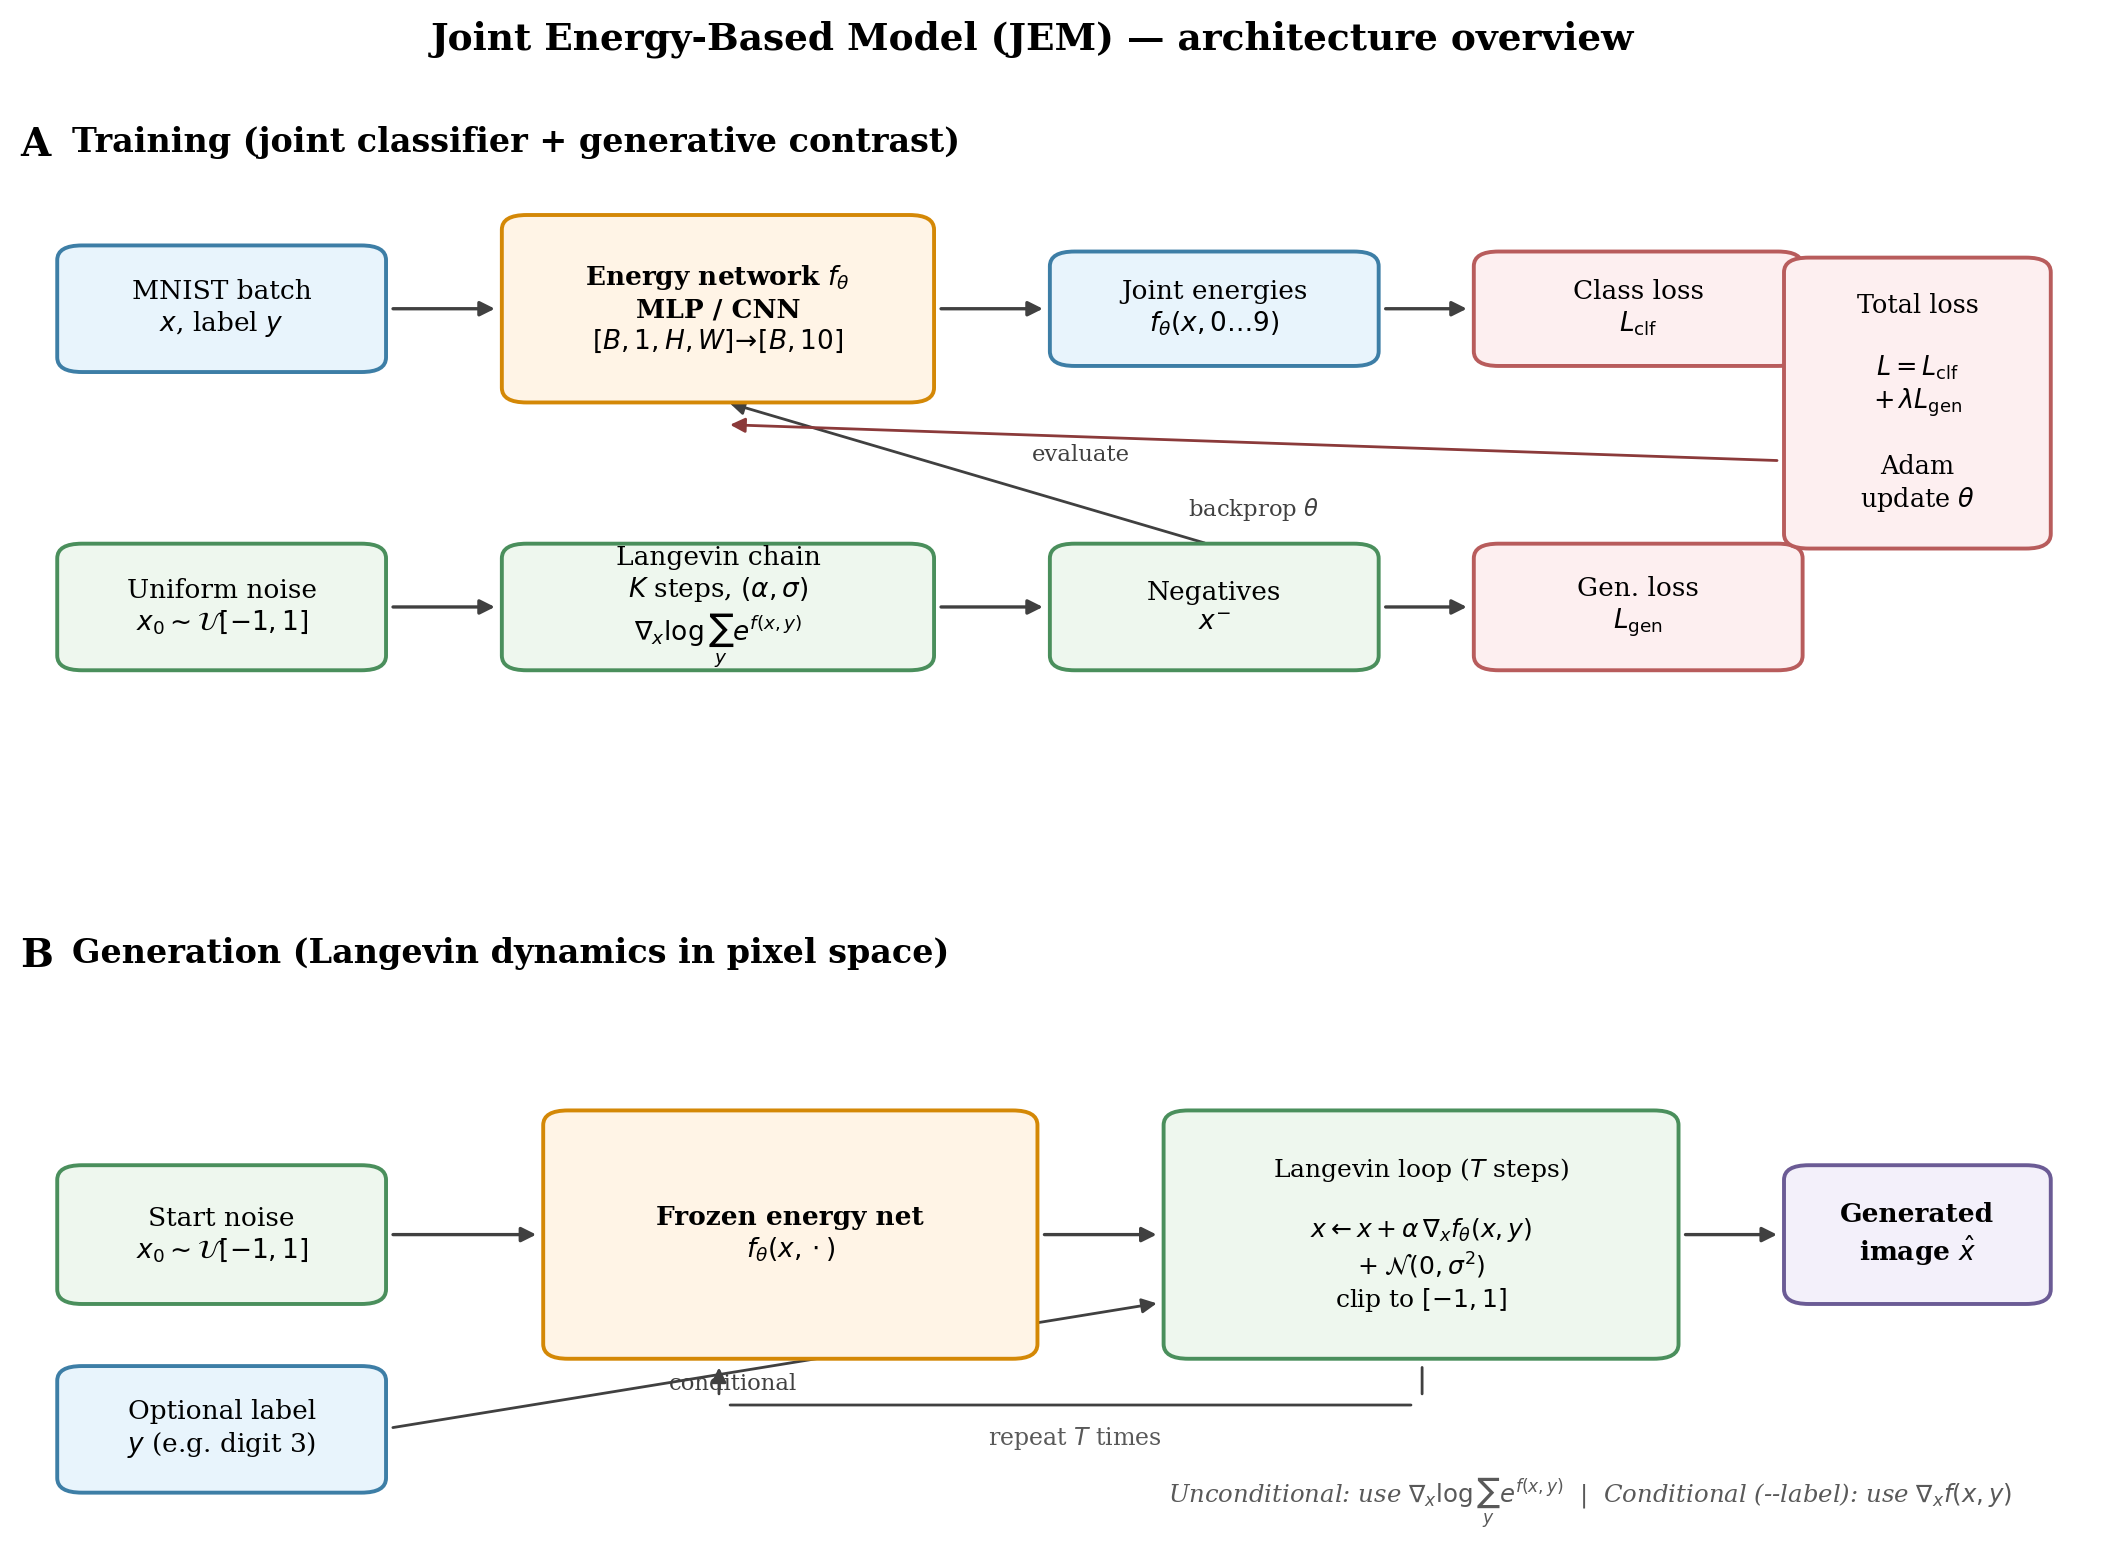

: 

In [ ]:
"""Publication-style architecture diagram for the joint EBM (ebm-digits)."""

from __future__ import annotations

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# Palette
C_NET = "#fff4e6"
C_NET_E = "#d48806"
C_DATA = "#e8f4fc"
C_DATA_E = "#3d7ea6"
C_PROC = "#eef7ee"
C_PROC_E = "#4a8f5c"
C_LOSS = "#fdeff0"
C_LOSS_E = "#b85c5c"
C_OUT = "#f3f0fa"
C_OUT_E = "#6b5b95"
ARROW = "#404040"


def box(ax, xy, w, h, text, fc, ec, fs=9.5, weight="normal"):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor=fc,
        edgecolor=ec,
        linewidth=1.4,
        zorder=2,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        fontweight=weight,
        zorder=3,
        linespacing=1.25,
    )
    return patch


def arrow(ax, start, end, text=None, text_offset=(0, 0), style="-|>", lw=1.2, color=ARROW):
    arr = FancyArrowPatch(
        start,
        end,
        arrowstyle=style,
        mutation_scale=11,
        linewidth=lw,
        color=color,
        shrinkA=4,
        shrinkB=4,
        connectionstyle="arc3,rad=0.0",
        zorder=1,
    )
    ax.add_patch(arr)
    if text:
        mx = (start[0] + end[0]) / 2 + text_offset[0]
        my = (start[1] + end[1]) / 2 + text_offset[1]
        ax.text(mx, my, text, ha="center", va="center", fontsize=8.2, color="0.25", zorder=4)


fig, axes = plt.subplots(2, 1, figsize=(11, 8.2), dpi=200)
fig.subplots_adjust(hspace=0.28, left=0.04, right=0.98, top=0.93, bottom=0.05)

# ── Panel A: Training ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 5.2)
ax.axis("off")
ax.text(0.0, 5.0, "A", fontsize=14, fontweight="bold", va="top")
ax.text(0.25, 5.0, "Training (joint classifier + generative contrast)", fontsize=12, fontweight="bold", va="top")

# Real data path
box(ax, (0.2, 3.0), 1.55, 1.0, "MNIST batch\n$x$, label $y$", C_DATA, C_DATA_E)
box(ax, (2.35, 2.75), 2.05, 1.5, "Energy network $f_\\theta$\nMLP / CNN\n$[B,1,H,W]\\!\\rightarrow\\![B,10]$", C_NET, C_NET_E, weight="bold")
box(ax, (5.0, 3.05), 1.55, 0.9, "Joint energies\n$f_\\theta(x,0\\ldots9)$", C_DATA, C_DATA_E)
box(ax, (7.05, 3.05), 1.55, 0.9, "Class loss\n$L_{\\mathrm{clf}}$", C_LOSS, C_LOSS_E)

arrow(ax, (1.75, 3.5), (2.35, 3.5))
arrow(ax, (4.4, 3.5), (5.0, 3.5))
arrow(ax, (6.55, 3.5), (7.05, 3.5))

# Negative sampling path
box(ax, (0.2, 0.55), 1.55, 1.0, "Uniform noise\n$x_0\\sim\\mathcal{U}[-1,1]$", C_PROC, C_PROC_E)
box(ax, (2.35, 0.55), 2.05, 1.0, "Langevin chain\n$K$ steps, $(\\alpha,\\sigma)$\n$\\nabla_x \\log\\sum_y e^{f(x,y)}$", C_PROC, C_PROC_E)
box(ax, (5.0, 0.55), 1.55, 1.0, "Negatives\n$x^{-}$", C_PROC, C_PROC_E)
box(ax, (7.05, 0.55), 1.55, 1.0, "Gen. loss\n$L_{\\mathrm{gen}}$", C_LOSS, C_LOSS_E)

arrow(ax, (1.75, 1.05), (2.35, 1.05))
arrow(ax, (4.4, 1.05), (5.0, 1.05))
arrow(ax, (6.55, 1.05), (7.05, 1.05))

# Energy net reused for negatives
arrow(ax, (5.78, 1.55), (3.38, 2.75), text="evaluate", text_offset=(0.55, 0.15), style="-|>", lw=1.0)

# Combined loss + optimizer
box(ax, (8.55, 1.55), 1.25, 2.35, "Total loss\n\n$L = L_{\\mathrm{clf}}$\n$+\\,\\lambda L_{\\mathrm{gen}}$\n\nAdam\nupdate $\\theta$", C_LOSS, C_LOSS_E, fs=9.2)
arrow(ax, (8.6, 3.5), (8.55, 3.2), lw=1.0)
arrow(ax, (8.6, 1.05), (8.55, 1.9), lw=1.0)
arrow(ax, (8.55, 2.25), (3.38, 2.55), text="backprop $\\theta$", text_offset=(0.0, -0.55), style="-|>", lw=1.0, color="#8b3a3a")

# ── Panel B: Sampling ────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 5.2)
ax.axis("off")
ax.text(0.0, 5.0, "B", fontsize=14, fontweight="bold", va="top")
ax.text(0.25, 5.0, "Generation (Langevin dynamics in pixel space)", fontsize=12, fontweight="bold", va="top")

box(ax, (0.2, 2.0), 1.55, 1.1, "Start noise\n$x_0 \\sim \\mathcal{U}[-1,1]$", C_PROC, C_PROC_E)
box(ax, (0.2, 0.45), 1.55, 1.0, "Optional label\n$y$ (e.g. digit 3)", C_DATA, C_DATA_E)
box(ax, (2.55, 1.55), 2.35, 2.0, "Frozen energy net\n$f_\\theta(x,\\cdot)$", C_NET, C_NET_E, weight="bold")
box(ax, (5.55, 1.55), 2.45, 2.0,
    "Langevin loop ($T$ steps)\n\n$x \\leftarrow x + \\alpha\\,\\nabla_x f_\\theta(x,y)$\n$+\\;\\mathcal{N}(0,\\sigma^2)$\nclip to $[-1,1]$",
    C_PROC, C_PROC_E, fs=9.0)
box(ax, (8.55, 2.0), 1.25, 1.1, "Generated\nimage $\\hat{x}$", C_OUT, C_OUT_E, weight="bold")

arrow(ax, (1.75, 2.55), (2.55, 2.55))
arrow(ax, (1.75, 0.95), (5.55, 2.0), text="conditional", text_offset=(-0.2, -0.15), style="-|>", lw=1.0)
arrow(ax, (4.9, 2.55), (5.55, 2.55))
arrow(ax, (8.0, 2.55), (8.55, 2.55))

# Feedback loop for Langevin iterations
arrow(ax, (6.78, 1.55), (6.78, 1.15), style="-", lw=1.0)
arrow(ax, (6.78, 1.15), (3.38, 1.15), style="-", lw=1.0)
arrow(ax, (3.38, 1.15), (3.38, 1.55), style="-|>", lw=1.0)
ax.text(5.1, 0.82, "repeat $T$ times", ha="center", fontsize=8.5, color="0.35")

# Marginal vs conditional note
ax.text(
    5.55,
    0.35,
    "Unconditional: use $\\nabla_x \\log\\sum_y e^{f(x,y)}$  |  Conditional (--label): use $\\nabla_x f(x,y)$",
    ha="left",
    fontsize=8.8,
    color="0.35",
    style="italic",
)

fig.suptitle("Joint Energy-Based Model (JEM) — architecture overview", fontsize=13.5, fontweight="bold", y=0.98)
plt.savefig("../runs/ebm_architecture.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("../runs/ebm_architecture.pdf", bbox_inches="tight", facecolor="white")
plt.show()